# Capítulo 1 — Datos, patrones y primeras predicciones

En el capítulo vimos que el Machine Learning permite construir sistemas que aprenden a partir de datos. En lugar de escribir manualmente todas las reglas posibles, buscamos que un modelo encuentre patrones y los use para responder ante casos nuevos.

En este cuaderno vamos a trabajar con una idea muy simple: observar datos, detectar una tendencia y usar esa tendencia para hacer una primera estimación.

Todavía no vamos a entrenar modelos con `scikit-learn`. Ese paso llegará más adelante. Por ahora, el objetivo es construir intuición: entender por qué los datos son tan importantes, qué significa encontrar un patrón y por qué una predicción no debe interpretarse como una certeza.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

* diferenciar una regla escrita manualmente de una respuesta basada en datos;
* reconocer un patrón simple en un conjunto de datos;
* usar una visualización para observar una relación entre variables;
* comprender que una predicción es una estimación aproximada;
* identificar algunas limitaciones iniciales del trabajo con datos.


## Una regla escrita a mano

Comencemos con una situación sencilla de programación tradicional.

Supongamos que queremos aplicar un descuento a una persona según su edad. En este caso, la regla es clara y puede escribirse directamente en el código: si la edad es mayor o igual a cierto valor, se aplica el descuento; si no, no se aplica.

Este tipo de problema no necesita Machine Learning. La regla ya está definida por una persona.


In [1]:
edad = 68

if edad >= 65:
    resultado = "Corresponde descuento"
else:
    resultado = "No corresponde descuento"

resultado

'Corresponde descuento'

La salida anterior muestra que el programa aplicó una regla escrita manualmente.

Esto es programación tradicional: una persona define la lógica y la computadora la ejecuta. Si conocemos la regla con claridad, este enfoque suele ser suficiente.

Pero no todos los problemas funcionan así. A veces no conocemos una regla exacta, o la regla sería demasiado difícil de escribir a mano. Por ejemplo: estimar el precio de una vivienda, detectar si un correo parece spam, recomendar una película o anticipar si un cliente podría abandonar un servicio.

En esos casos, en lugar de escribir todas las reglas posibles, podemos mirar datos y buscar patrones.


## Un pequeño conjunto de datos

Supongamos que tenemos información sobre algunas viviendas. Para cada una conocemos su superficie, medida en metros cuadrados, y su precio, expresado en miles de dólares.

El objetivo no es construir todavía un modelo de Machine Learning completo. Por ahora solo queremos observar los datos y preguntarnos si parece haber algún patrón.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

datos = {
    "superficie_m2": [35, 42, 50, 58, 65, 72, 80, 88, 95, 105, 115, 125],
    "precio_miles_usd": [52, 58, 68, 73, 82, 91, 99, 108, 116, 130, 139, 151]
}

df = pd.DataFrame(datos)

df

,superficie_m2,precio_miles_usd
0,35,52
1,42,58
2,50,68
3,58,73
4,65,82
5,72,91
6,80,99
7,88,108
8,95,116
9,105,130


El DataFrame contiene 12 viviendas. Para cada vivienda conocemos dos datos:

* `superficie_m2`: superficie de la vivienda en metros cuadrados.
* `precio_miles_usd`: precio de la vivienda expresado en miles de dólares.

A simple vista parece que, a medida que aumenta la superficie, también aumenta el precio. Pero antes de sacar conclusiones, conviene observar los datos con algunas herramientas básicas.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   superficie_m2     12 non-null     int64
 1   precio_miles_usd  12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes


In [4]:
df.describe()

,superficie_m2,precio_miles_usd
count,12.000000,12.000000
mean,77.500000,97.250000
std,28.968635,32.302899
min,35.000000,52.000000
25%,56.000000,71.750000
50%,76.000000,95.000000
75%,97.500000,119.500000
max,125.000000,151.000000


## Observar un patrón

Una tabla puede mostrar los datos, pero muchas veces un gráfico permite ver relaciones con más claridad.

En este caso vamos a hacer un gráfico de dispersión. Cada punto representa una vivienda. En el eje horizontal ubicaremos la superficie, y en el eje vertical ubicaremos el precio.

Si los puntos muestran una tendencia clara, podremos decir que hay un patrón visible en los datos.


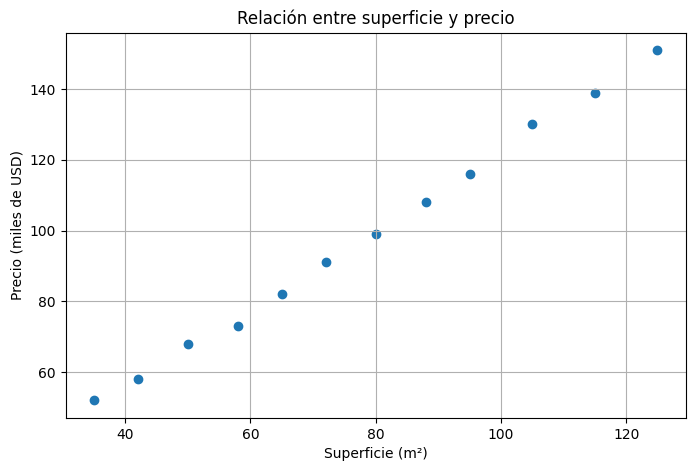

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["superficie_m2"],
    df["precio_miles_usd"]
)

plt.title("Relación entre superficie y precio")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)

plt.show()

El gráfico muestra una tendencia ascendente: las viviendas con mayor superficie suelen tener precios más altos.

Esto no significa que podamos predecir el precio exacto de cualquier vivienda. En la vida real, el precio también depende de muchas otras variables, como la ubicación, la antigüedad, el estado general, la cantidad de ambientes, los servicios disponibles y el contexto del mercado.

Sin embargo, con estos datos simples ya podemos ver una idea importante: cuando existe un patrón, podemos usarlo para hacer una estimación aproximada sobre un caso nuevo.


## Una línea que resume la tendencia

Para ayudarnos a visualizar mejor el patrón, podemos dibujar una línea que acompañe la tendencia general de los puntos.

En capítulos posteriores veremos modelos formales para hacer este tipo de estimaciones. Por ahora, usaremos esta línea solo como una ayuda visual: una forma sencilla de resumir la relación entre superficie y precio.


In [6]:
import numpy as np

x = df["superficie_m2"]
y = df["precio_miles_usd"]

pendiente, intercepto = np.polyfit(x, y, 1)

pendiente, intercepto

(np.float64(1.114017982883761), np.float64(10.913606326508528))

La línea de tendencia queda definida por dos valores:

* una pendiente, que indica cuánto cambia aproximadamente el precio cuando cambia la superficie;
* un intercepto, que ayuda a ubicar la línea en el gráfico.

No hace falta memorizar estos términos ahora. Lo importante es entender la idea: estamos usando los datos disponibles para construir una regla aproximada que resume el patrón observado.


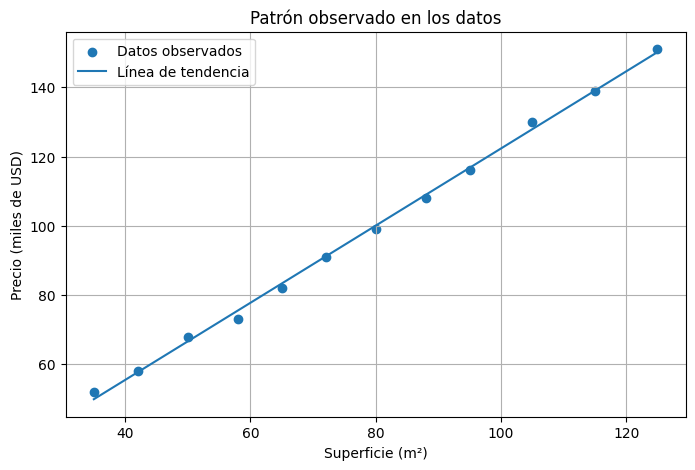

In [7]:
precios_estimados = pendiente * x + intercepto

plt.figure(figsize=(8, 5))

plt.scatter(
    df["superficie_m2"],
    df["precio_miles_usd"],
    label="Datos observados"
)

plt.plot(
    df["superficie_m2"],
    precios_estimados,
    label="Línea de tendencia"
)

plt.title("Patrón observado en los datos")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)
plt.legend()

plt.show()

La línea de tendencia resume el patrón general que aparece en los datos.

En este ejemplo, los puntos están bastante cerca de la línea. Eso indica que, dentro de este pequeño conjunto de datos, la superficie parece estar muy relacionada con el precio.

Sin embargo, esta línea no debe interpretarse como una verdad absoluta. Es una simplificación construida a partir de los datos disponibles. Si los datos fueran otros, si hubiera más viviendas o si incluyéramos variables como ubicación o antigüedad, la tendencia podría cambiar.


## Estimar un caso nuevo

Supongamos que queremos estimar el precio de una vivienda de 90 m².

Esa vivienda no está en nuestra tabla original. Por lo tanto, no estamos consultando un dato conocido. Estamos usando el patrón observado para hacer una estimación sobre un caso nuevo.

Esta es una primera aproximación a una idea central de Machine Learning: usar lo aprendido a partir de datos previos para responder ante datos que no vimos antes.


In [8]:
superficie_nueva = 90

precio_estimado = pendiente * superficie_nueva + intercepto

precio_estimado

np.float64(111.17522478604702)

La estimación obtenida fue de aproximadamente 111,18 miles de dólares.

Esto no significa que una vivienda de 90 m² deba valer exactamente ese precio. Significa que, según el patrón observado en nuestro pequeño conjunto de datos, ese sería un valor razonable dentro de la tendencia general.

Esta diferencia es importante: una predicción no es una certeza. Es una respuesta aproximada basada en los datos disponibles.


In [9]:
print(f"Precio estimado para una vivienda de {superficie_nueva} m²: {precio_estimado:.2f} miles de USD")

Precio estimado para una vivienda de 90 m²: 111.18 miles de USD


Ahora la estimación aparece en un formato más fácil de leer.

Según los datos que usamos, una vivienda de 90 m² tendría un precio estimado de aproximadamente 111,18 miles de dólares.

Pero esta respuesta depende completamente del patrón observado en nuestro conjunto de datos. Si los datos fueran pocos, estuvieran sesgados, tuvieran errores o no representaran bien el problema real, la estimación podría ser engañosa.


## Visualizar la estimación

Podemos agregar la vivienda nueva al gráfico para ver dónde queda ubicada respecto de los datos originales y de la línea de tendencia.

Esto ayuda a distinguir entre dos cosas:

los datos observados, que ya estaban en nuestra tabla;

la estimación, que corresponde a un caso nuevo.


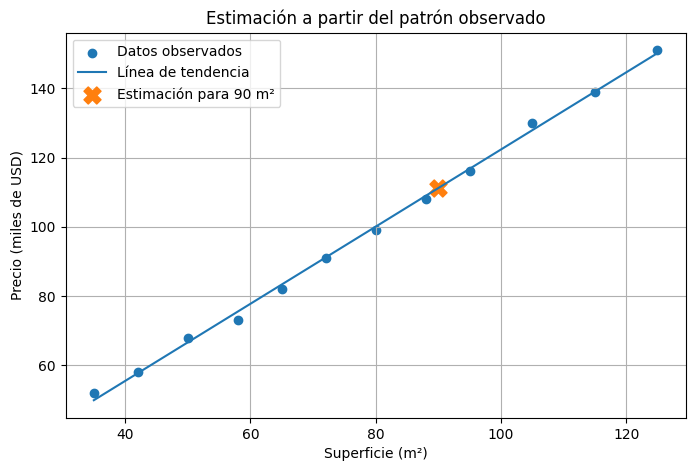

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["superficie_m2"],
    df["precio_miles_usd"],
    label="Datos observados"
)

plt.plot(
    df["superficie_m2"],
    precios_estimados,
    label="Línea de tendencia"
)

plt.scatter(
    superficie_nueva,
    precio_estimado,
    marker="X",
    s=150,
    label="Estimación para 90 m²"
)

plt.title("Estimación a partir del patrón observado")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)
plt.legend()

plt.show()

La vivienda de 90 m² no estaba en el DataFrame original. El valor que obtuvimos no salió de una fila ya existente, sino de una regla aproximada construida a partir de los datos.

Esto se parece a lo que buscamos en Machine Learning: que el sistema pueda usar patrones aprendidos en datos conocidos para responder ante casos nuevos.

A esa capacidad la llamamos generalización.

Pero generalizar no significa adivinar correctamente cualquier caso. El resultado depende de los datos disponibles, del patrón que exista en ellos y de si el nuevo caso se parece razonablemente a los casos usados para construir la regla.


## Estimar dentro y fuera del rango observado

Nuestro conjunto de datos contiene viviendas entre 35 m² y 125 m².

Estimar el precio de una vivienda de 90 m² parece razonable, porque 90 está dentro del rango observado.

Pero ¿qué ocurriría si quisiéramos estimar el precio de una vivienda de 250 m²? En ese caso estaríamos usando el patrón mucho más allá de los datos que tenemos. La estimación podría existir matemáticamente, pero sería menos confiable.


In [11]:
superficies_nuevas = [90, 250]

for superficie in superficies_nuevas:
    precio = pendiente * superficie + intercepto
    print(f"Superficie: {superficie} m² -> Precio estimado: {precio:.2f} miles de USD")

Superficie: 90 m² -> Precio estimado: 111.18 miles de USD
Superficie: 250 m² -> Precio estimado: 289.42 miles de USD


Las dos estimaciones se calcularon con la misma regla aproximada, pero no tienen el mismo nivel de confianza.

La vivienda de 90 m² está dentro del rango observado en los datos originales. En cambio, la vivienda de 250 m² está muy por fuera de ese rango, porque nuestro dataset solo incluye viviendas entre 35 m² y 125 m².

Cuando usamos un patrón fuera del rango en el que fue observado, la estimación puede volverse poco confiable. El cálculo puede parecer preciso, pero eso no significa que represente bien la realidad.

Esta es una advertencia importante: los modelos no “saben” automáticamente cuándo están siendo usados en situaciones muy distintas de aquellas que vieron en los datos.


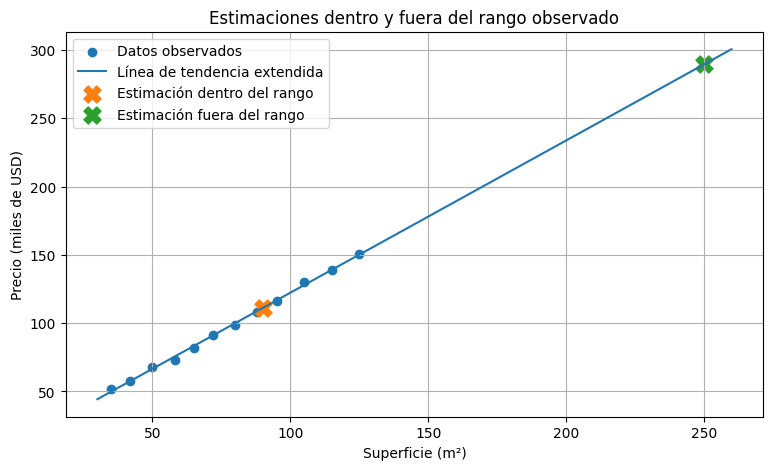

In [12]:
superficies_para_linea = np.linspace(30, 260, 100)
precios_para_linea = pendiente * superficies_para_linea + intercepto

precio_90 = pendiente * 90 + intercepto
precio_250 = pendiente * 250 + intercepto

plt.figure(figsize=(9, 5))

plt.scatter(
    df["superficie_m2"],
    df["precio_miles_usd"],
    label="Datos observados"
)

plt.plot(
    superficies_para_linea,
    precios_para_linea,
    label="Línea de tendencia extendida"
)

plt.scatter(
    90,
    precio_90,
    marker="X",
    s=150,
    label="Estimación dentro del rango"
)

plt.scatter(
    250,
    precio_250,
    marker="X",
    s=150,
    label="Estimación fuera del rango"
)

plt.title("Estimaciones dentro y fuera del rango observado")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)
plt.legend()

plt.show()

El gráfico permite ver claramente la diferencia entre las dos situaciones.

La estimación para 90 m² se ubica dentro de la zona donde tenemos datos observados. En cambio, la estimación para 250 m² queda muy lejos de todos los puntos originales.

Esto no significa que la estimación de 250 m² sea necesariamente falsa, pero sí significa que deberíamos tomarla con mucha más precaución. Estamos usando una tendencia observada en viviendas pequeñas y medianas para estimar una vivienda mucho más grande.

En Machine Learning, esta idea aparece constantemente: un sistema suele funcionar mejor cuando los casos nuevos se parecen a los datos con los que aprendió. Cuando los casos nuevos son muy distintos, las predicciones pueden volverse menos confiables.


## Los datos condicionan lo que podemos aprender

Hasta ahora trabajamos con un conjunto de datos muy ordenado. Los puntos seguían una tendencia clara y eso nos permitió construir una estimación razonable.

Pero en problemas reales los datos pueden ser más difíciles. Pueden tener errores, valores faltantes, casos poco representativos o variables importantes que no fueron registradas.

Para ver esta idea, vamos a crear una segunda versión del dataset con algunos precios más irregulares.


In [13]:
df_irregular = df.copy()

df_irregular["precio_miles_usd"] = [52, 70, 61, 90, 78, 95, 88, 125, 103, 145, 120, 170]

df_irregular

,superficie_m2,precio_miles_usd
0,35,52
1,42,70
2,50,61
3,58,90
4,65,78
5,72,95
6,80,88
7,88,125
8,95,103
9,105,145


En este nuevo DataFrame seguimos teniendo las mismas superficies, pero los precios son más irregulares.

La relación entre superficie y precio no desaparece por completo, pero ahora es menos ordenada. Esto puede representar situaciones reales: dos viviendas con superficies parecidas pueden tener precios distintos por su ubicación, estado, antigüedad, calidad de construcción o muchas otras variables que no estamos considerando.

Cuando los datos son más irregulares, encontrar un patrón puede ser más difícil y las estimaciones pueden volverse menos confiables.


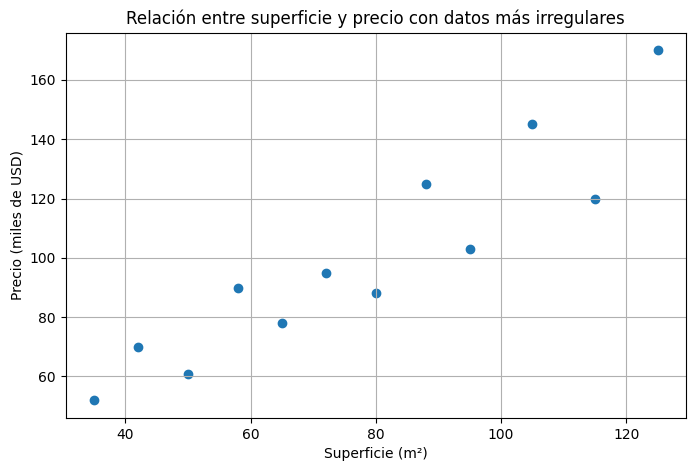

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_irregular["superficie_m2"],
    df_irregular["precio_miles_usd"]
)

plt.title("Relación entre superficie y precio con datos más irregulares")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)

plt.show()

El segundo gráfico muestra una relación menos ordenada que la anterior.

Todavía parece haber una tendencia general: las viviendas más grandes tienden a tener precios más altos. Sin embargo, los puntos ya no siguen una línea tan clara.

Esto nos recuerda una idea importante: los datos reales suelen tener variabilidad. Aunque exista un patrón, ese patrón puede estar mezclado con ruido, diferencias entre casos, errores de medición o variables importantes que no fueron registradas.

Por eso, en Machine Learning no alcanza con encontrar una relación visual. Más adelante necesitaremos aprender a entrenar modelos, evaluarlos y analizar qué tan bien funcionan con datos nuevos.


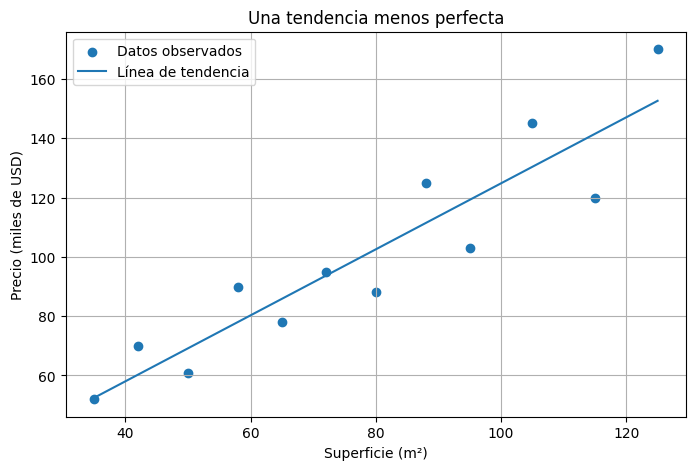

In [15]:
x_irregular = df_irregular["superficie_m2"]
y_irregular = df_irregular["precio_miles_usd"]

pendiente_irregular, intercepto_irregular = np.polyfit(x_irregular, y_irregular, 1)

precios_estimados_irregular = pendiente_irregular * x_irregular + intercepto_irregular

plt.figure(figsize=(8, 5))

plt.scatter(
    x_irregular,
    y_irregular,
    label="Datos observados"
)

plt.plot(
    x_irregular,
    precios_estimados_irregular,
    label="Línea de tendencia"
)

plt.title("Una tendencia menos perfecta")
plt.xlabel("Superficie (m²)")
plt.ylabel("Precio (miles de USD)")
plt.grid(True)
plt.legend()

plt.show()

La línea de tendencia todavía resume una relación general entre superficie y precio, pero ahora los puntos están más dispersos.

Esto muestra que un patrón puede existir aunque los datos no sean perfectos. En problemas reales, los modelos deben aprender a trabajar con esa variabilidad.

También muestra una limitación importante: si solo usamos la superficie, dejamos afuera muchos factores que podrían influir en el precio. Tal vez dos viviendas tengan la misma superficie, pero una esté mejor ubicada, sea más nueva o tenga mejores servicios.

Por eso, los datos disponibles condicionan lo que podemos aprender. Un modelo no puede usar información que no está en el dataset.


## Cierre del cuaderno

En este cuaderno trabajamos con una idea central del Machine Learning: usar datos para encontrar patrones y hacer estimaciones sobre casos nuevos.

Primero vimos un ejemplo de programación tradicional, donde la regla estaba escrita manualmente. Luego trabajamos con un pequeño conjunto de datos de viviendas, observamos una relación entre superficie y precio, dibujamos una línea de tendencia y la usamos para estimar el precio de una vivienda nueva.

También vimos dos advertencias importantes.

La primera es que una predicción no es una certeza. Es una estimación basada en los datos disponibles.

La segunda es que no todas las estimaciones tienen el mismo nivel de confianza. Estimar dentro del rango observado es distinto de usar una tendencia para responder sobre casos muy alejados de los datos originales.

En los próximos capítulos vamos a avanzar sobre distintos tipos de problemas de Machine Learning y empezaremos a usar herramientas específicas para construir modelos de manera más formal.


## Para pensar

Antes de seguir, respondé con tus propias palabras:

1. ¿Por qué el ejemplo del descuento por edad no necesitaba Machine Learning?
2. ¿Qué patrón observamos en los datos de viviendas?
3. ¿Por qué la estimación para 250 m² era menos confiable que la estimación para 90 m²?
4. ¿Qué información adicional podría mejorar una estimación del precio de una vivienda?

Estas preguntas no buscan una respuesta única. Sirven para revisar las ideas principales antes de avanzar hacia los próximos capítulos.
